# Static One-Day VaR and Expected Shortfall Models

## 1. Objective

This notebook estimates static one-day Value at Risk (VaR) and Expected Shortfall (ES) for the fixed-weight ETF portfolio using three approaches: Historical, Parametric Normal, and Monte Carlo Normal.

The analysis uses the complete processed sample from `2018-01-03` to `2026-09-21`. It demonstrates model mechanics and describes the sample's risk level; it is **not** an out-of-sample forecast or evidence that any model is reliable. Rolling estimation, backtesting, Kupiec and Christoffersen tests, and stress testing are intentionally deferred.

Headline result: the return sample is only mildly negatively skewed (`-0.099`) but has high excess kurtosis (`8.714`). Consistent with those fat tails, Historical 99% VaR and ES exceed the two Normal-model estimates, while the Normal 95% VaR is slightly above Historical 95% VaR.

## 2. Methodology and Risk Conventions

The common conventions keep signs and units comparable across models:

- Input returns are simple daily returns generated in the prior stage; they are read, not recomputed.
- One-day portfolio loss is `loss = -portfolio_return`.
- VaR and ES are positive loss numbers. For example, a return-form VaR of `0.025` is displayed as `2.50%`, not `0.025%`.
- Confidence levels are 95% and 99%, with a one-trading-day holding period.
- The illustrative portfolio value is USD 1,000,000.
- The portfolio is treated as a daily rebalanced constant-weight portfolio. Transaction costs, turnover, taxes, and implementation frictions are excluded.
- Historical and Monte Carlo empirical quantiles use NumPy's explicit `method="linear"` rule. If sorted losses are `x`, `h=(n-1)c`, `j=floor(h)`, and `g=h-j`, the quantile is `(1-g)x[j] + g x[j+1]`.
- ES is the mean of losses satisfying `loss >= VaR`.

Reported return and percentage measures describe the same number in different units; USD measures equal the return-form risk multiplied by the portfolio value.

## 3. Data Loading and Validation

### 3.1 Setup and Fixed Parameters

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from scipy import stats
from scipy.stats import norm

project_root = Path.cwd().resolve()
if not (project_root / "data" / "processed" / "asset_returns.csv").exists():
    project_root = project_root.parent

ASSET_RETURNS_PATH = project_root / "data" / "processed" / "asset_returns.csv"
PORTFOLIO_RETURNS_PATH = project_root / "data" / "processed" / "portfolio_returns.csv"
RESULTS_PATH = project_root / "outputs" / "tables" / "static_var_es_results.csv"
DISTRIBUTION_FIGURE_PATH = (
    project_root / "outputs" / "figures" / "portfolio_return_distribution.png"
)
COMPARISON_FIGURE_PATH = (
    project_root / "outputs" / "figures" / "static_var_es_comparison.png"
)

TICKERS = ["SPY", "QQQ", "TLT", "GLD"]
CONFIDENCE_LEVELS = (0.95, 0.99)
PORTFOLIO_VALUE = 1_000_000.0
HOLDING_PERIOD = "1 trading day"
QUANTILE_METHOD = "linear"
SIMULATIONS = 100_000
RANDOM_SEED = 42
WEIGHTS = pd.Series(
    {"SPY": 0.40, "QQQ": 0.25, "TLT": 0.20, "GLD": 0.15},
    dtype="float64",
    name="Weight",
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "legend.frameon": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(
    "Asset returns source:     "
    f"{ASSET_RETURNS_PATH.relative_to(project_root)}"
)
print(
    "Portfolio returns source: "
    f"{PORTFOLIO_RETURNS_PATH.relative_to(project_root)}"
)

Asset returns source:     data/processed/asset_returns.csv
Portfolio returns source: data/processed/portfolio_returns.csv


### 3.2 Load Processed Returns Without Recalculation

In [2]:
asset_returns = pd.read_csv(
    ASSET_RETURNS_PATH,
    index_col="Date",
    parse_dates=True,
)
portfolio_frame = pd.read_csv(
    PORTFOLIO_RETURNS_PATH,
    index_col="Date",
    parse_dates=True,
)

assert isinstance(asset_returns.index, pd.DatetimeIndex)
assert isinstance(portfolio_frame.index, pd.DatetimeIndex)
assert asset_returns.index.is_monotonic_increasing
assert portfolio_frame.index.is_monotonic_increasing
assert not asset_returns.index.has_duplicates
assert not portfolio_frame.index.has_duplicates
assert not asset_returns.isna().any().any()
assert not portfolio_frame.isna().any().any()
assert asset_returns.index.equals(portfolio_frame.index)
assert asset_returns.columns.tolist() == TICKERS
assert portfolio_frame.columns.tolist() == ["Portfolio"]
assert len(asset_returns) == len(portfolio_frame) > 0

portfolio_returns = portfolio_frame["Portfolio"].copy()
sample_start = asset_returns.index.min()
sample_end = asset_returns.index.max()
observations = len(asset_returns)

input_validation = pd.Series(
    {
        "Observations": observations,
        "Sample start": sample_start.date().isoformat(),
        "Sample end": sample_end.date().isoformat(),
        "Asset columns": ", ".join(asset_returns.columns),
        "Portfolio column": portfolio_returns.name,
        "Duplicate dates": int(asset_returns.index.duplicated().sum()),
        "Asset missing values": int(asset_returns.isna().sum().sum()),
        "Portfolio missing values": int(portfolio_returns.isna().sum()),
        "Dates aligned": asset_returns.index.equals(portfolio_returns.index),
    },
    name="Validation result",
)
display(input_validation.to_frame())
display(pd.concat([asset_returns.head(3), portfolio_returns.head(3)], axis=1))

,Validation result
Observations,2190
Sample start,2018-01-03
Sample end,2026-09-21
Asset columns,"SPY, QQQ, TLT, GLD"
Portfolio column,Portfolio
Duplicate dates,0
Asset missing values,0
Portfolio missing values,0
Dates aligned,True


,SPY,QQQ,TLT,GLD,Portfolio
Date,,,,,
2018-01-03,0.006325,0.009717,0.004781,-0.002637,0.005520
2018-01-04,0.004215,0.001749,-0.000158,0.005127,0.002861
2018-01-05,0.006664,0.010043,-0.002856,-0.001036,0.004450


## 4. Portfolio Return Diagnostics

In [3]:
mean_return = float(portfolio_returns.mean())
std_return = float(portfolio_returns.std(ddof=1))
min_return = float(portfolio_returns.min())
max_return = float(portfolio_returns.max())
return_skewness = float(stats.skew(portfolio_returns, bias=False))
excess_kurtosis = float(
    stats.kurtosis(portfolio_returns, fisher=True, bias=False)
)
return_quantile_1pct = float(
    np.quantile(portfolio_returns, 0.01, method=QUANTILE_METHOD)
)
return_quantile_5pct = float(
    np.quantile(portfolio_returns, 0.05, method=QUANTILE_METHOD)
)

diagnostic_statistics = pd.Series(
    {
        "Mean": mean_return,
        "Standard deviation (ddof=1)": std_return,
        "Minimum": min_return,
        "Maximum": max_return,
        "Skewness": return_skewness,
        "Excess kurtosis": excess_kurtosis,
        "1% quantile": return_quantile_1pct,
        "5% quantile": return_quantile_5pct,
        "Observation count": observations,
    },
    name="Portfolio return",
)
display(diagnostic_statistics.to_frame().style.format("{:.6f}"))

,Portfolio return
Mean,0.000538
Standard deviation (ddof=1),0.008842
Minimum,-0.065938
Maximum,0.078741
Skewness,-0.099289
Excess kurtosis,8.713643
1% quantile,-0.024275
5% quantile,-0.013701
Observation count,2190.000000


The observed skewness of `-0.099` indicates only mild downside asymmetry in the full sample. Excess kurtosis of `8.714`, however, is far above the Normal benchmark of zero and supports a fat-tail interpretation. A Normal model can therefore miss the frequency or severity of extreme moves even when mean and standard deviation are estimated correctly.

## 5. Historical VaR and ES

Historical risk estimates use the actual portfolio loss series without imposing a distribution. VaR is the linear empirical quantile, and ES averages all observed losses at or above that threshold. The tail count is deliberately reported because the 99% estimate is supported by relatively few observations.

In [4]:
portfolio_losses = -portfolio_returns.to_numpy(dtype="float64")

def empirical_var_es(loss_values, confidence_level, quantile_method="linear"):
    var_value = float(
        np.quantile(
            loss_values,
            confidence_level,
            method=quantile_method,
        )
    )
    tail_losses = loss_values[loss_values >= var_value]
    es_value = float(tail_losses.mean())
    return {
        "VaR": var_value,
        "ES": es_value,
        "Tail_Count": int(tail_losses.size),
        "Tail_Fraction": float(tail_losses.size / loss_values.size),
    }

historical_estimates = {
    confidence: empirical_var_es(
        portfolio_losses,
        confidence,
        quantile_method=QUANTILE_METHOD,
    )
    for confidence in CONFIDENCE_LEVELS
}

historical_diagnostics = pd.DataFrame(
    [
        {
            "Confidence_Level": confidence,
            "VaR_Return": estimate["VaR"],
            "ES_Return": estimate["ES"],
            "Tail_Count": estimate["Tail_Count"],
            "Tail_Fraction": estimate["Tail_Fraction"],
        }
        for confidence, estimate in historical_estimates.items()
    ]
)
display(
    historical_diagnostics.style.format(
        {
            "Confidence_Level": "{:.0%}",
            "VaR_Return": "{:.4%}",
            "ES_Return": "{:.4%}",
            "Tail_Count": "{:,.0f}",
            "Tail_Fraction": "{:.4%}",
        }
    )
)

,Confidence_Level,VaR_Return,ES_Return,Tail_Count,Tail_Fraction
0,95%,1.3701%,2.0605%,110,5.0228%
1,99%,2.4275%,3.4268%,22,1.0046%


Historical 95% VaR is about `1.370%`, while ES rises to `2.060%`. At 99%, VaR is about `2.427%` and ES is `3.427%`. Only 22 observations enter the 99% ES tail, so that estimate describes the realized sample but is sensitive to which market regimes and extreme days are included.

## 6. Parametric Normal VaR and ES

The Parametric Normal model assumes the portfolio return follows a Normal distribution with the observed daily mean and sample standard deviation:

```text
R_p ~ Normal(mean_return, std_return²)
loss = -R_p
z_c = norm.ppf(c)
VaR_c = -mean_return + std_return × z_c
ES_c  = -mean_return + std_return × norm.pdf(z_c) / (1 - c)
```

Here `c` is the confidence level, `z_c` is its standard Normal quantile, and `norm.pdf(z_c)` is the standard Normal density evaluated at that quantile. The negative mean appears because risk is expressed as positive loss. No absolute value is used; sign consistency comes directly from the loss definition.

In [5]:
parametric_estimates = {}
for confidence in CONFIDENCE_LEVELS:
    z_score = float(norm.ppf(confidence))
    var_value = float(-mean_return + std_return * z_score)
    es_value = float(
        -mean_return
        + std_return * norm.pdf(z_score) / (1.0 - confidence)
    )
    parametric_estimates[confidence] = {
        "VaR": var_value,
        "ES": es_value,
        "Z_Score": z_score,
    }

parametric_values = np.array(
    [
        value
        for estimate in parametric_estimates.values()
        for value in (estimate["VaR"], estimate["ES"])
    ]
)
assert np.isfinite(parametric_values).all()
assert parametric_estimates[0.99]["VaR"] >= parametric_estimates[0.95]["VaR"]
assert parametric_estimates[0.95]["ES"] >= parametric_estimates[0.95]["VaR"]
assert parametric_estimates[0.99]["ES"] >= parametric_estimates[0.99]["VaR"]

parametric_table = pd.DataFrame(
    [
        {
            "Confidence_Level": confidence,
            "Z_Score": estimate["Z_Score"],
            "VaR_Return": estimate["VaR"],
            "ES_Return": estimate["ES"],
        }
        for confidence, estimate in parametric_estimates.items()
    ]
)
display(
    parametric_table.style.format(
        {
            "Confidence_Level": "{:.0%}",
            "Z_Score": "{:.4f}",
            "VaR_Return": "{:.4%}",
            "ES_Return": "{:.4%}",
        }
    )
)

,Confidence_Level,Z_Score,VaR_Return,ES_Return
0,95%,1.6449,1.4005%,1.7700%
1,99%,2.3263,2.0031%,2.3027%


## 7. Monte Carlo VaR and ES

The Monte Carlo model draws 100,000 joint one-day asset returns from a four-variable Normal distribution using the historical asset mean vector and sample covariance matrix. Independent standard Normal draws are transformed with the covariance matrix's Cholesky factor, and the fixed portfolio weights convert all simulated asset rows to portfolio returns in vectorized calculations.

In [6]:
WEIGHTS = WEIGHTS.reindex(TICKERS)
asset_mean_vector = asset_returns[TICKERS].mean().to_numpy(dtype="float64")
asset_covariance_matrix = asset_returns[TICKERS].cov(ddof=1).to_numpy(
    dtype="float64"
)

assert np.isclose(WEIGHTS.sum(), 1.0)
assert np.isfinite(asset_mean_vector).all()
assert np.isfinite(asset_covariance_matrix).all()
assert np.allclose(
    asset_covariance_matrix,
    asset_covariance_matrix.T,
    rtol=1e-12,
    atol=1e-15,
)

cholesky_factor = np.linalg.cholesky(asset_covariance_matrix)
rng = np.random.default_rng(RANDOM_SEED)
standard_normal_draws = rng.standard_normal((SIMULATIONS, len(TICKERS)))
simulated_asset_returns = asset_mean_vector + np.einsum(
    "ij,kj->ki",
    cholesky_factor,
    standard_normal_draws,
    optimize=False,
)
simulated_portfolio_returns = np.sum(
    simulated_asset_returns * WEIGHTS.to_numpy(),
    axis=1,
)
simulated_losses = -simulated_portfolio_returns

assert standard_normal_draws.shape == (SIMULATIONS, len(TICKERS))
assert simulated_asset_returns.shape == (SIMULATIONS, len(TICKERS))
assert simulated_portfolio_returns.shape == (SIMULATIONS,)
assert np.isfinite(simulated_asset_returns).all()
assert np.isfinite(simulated_portfolio_returns).all()
assert np.isfinite(simulated_losses).all()

monte_carlo_estimates = {
    confidence: empirical_var_es(
        simulated_losses,
        confidence,
        quantile_method=QUANTILE_METHOD,
    )
    for confidence in CONFIDENCE_LEVELS
}

monte_carlo_table = pd.DataFrame(
    [
        {
            "Confidence_Level": confidence,
            "VaR_Return": estimate["VaR"],
            "ES_Return": estimate["ES"],
            "Tail_Count": estimate["Tail_Count"],
        }
        for confidence, estimate in monte_carlo_estimates.items()
    ]
)
display(
    monte_carlo_table.style.format(
        {
            "Confidence_Level": "{:.0%}",
            "VaR_Return": "{:.4%}",
            "ES_Return": "{:.4%}",
            "Tail_Count": "{:,.0f}",
        }
    )
)

,Confidence_Level,VaR_Return,ES_Return,Tail_Count
0,95%,1.3983%,1.7660%,"5,000"
1,99%,1.9984%,2.2873%,"1,000"


Monte Carlo Normal and Parametric Normal use the same core distributional assumption. Their estimates should therefore be close apart from finite-simulation noise. Agreement between them is a consistency check, not independent model validation and not evidence that Normal tails fit the data.

## 8. Model Comparison

### 8.1 Unified Numeric Results

In [7]:
estimate_sets = {
    "Historical": historical_estimates,
    "Parametric Normal": parametric_estimates,
    "Monte Carlo Normal": monte_carlo_estimates,
}

result_rows = []
for model_name, model_estimates in estimate_sets.items():
    for confidence in CONFIDENCE_LEVELS:
        var_return = float(model_estimates[confidence]["VaR"])
        es_return = float(model_estimates[confidence]["ES"])
        result_rows.append(
            {
                "Model": model_name,
                "Confidence_Level": float(confidence),
                "VaR_Return": var_return,
                "ES_Return": es_return,
                "VaR_Percent": var_return * 100.0,
                "ES_Percent": es_return * 100.0,
                "VaR_USD": var_return * PORTFOLIO_VALUE,
                "ES_USD": es_return * PORTFOLIO_VALUE,
                "Portfolio_Value": PORTFOLIO_VALUE,
                "Holding_Period": HOLDING_PERIOD,
                "Sample_Start": sample_start.date().isoformat(),
                "Sample_End": sample_end.date().isoformat(),
                "Observations": observations,
            }
        )

results_table = pd.DataFrame(result_rows)
numeric_risk_columns = [
    "Confidence_Level",
    "VaR_Return",
    "ES_Return",
    "VaR_Percent",
    "ES_Percent",
    "VaR_USD",
    "ES_USD",
    "Portfolio_Value",
    "Observations",
]

assert np.isfinite(results_table[numeric_risk_columns].to_numpy()).all()
assert (results_table["VaR_Return"] > 0).all()
assert (results_table["ES_Return"] >= results_table["VaR_Return"]).all()
for model_name, model_rows in results_table.groupby("Model", sort=False):
    indexed = model_rows.set_index("Confidence_Level")
    assert indexed.loc[0.99, "VaR_Return"] >= indexed.loc[0.95, "VaR_Return"]
    assert indexed.loc[0.99, "ES_Return"] >= indexed.loc[0.95, "ES_Return"]

display(
    results_table.style.format(
        {
            "Confidence_Level": "{:.0%}",
            "VaR_Return": "{:.6f}",
            "ES_Return": "{:.6f}",
            "VaR_Percent": "{:.3f}%",
            "ES_Percent": "{:.3f}%",
            "VaR_USD": "USD {:,.2f}",
            "ES_USD": "USD {:,.2f}",
            "Portfolio_Value": "USD {:,.0f}",
            "Observations": "{:,.0f}",
        }
    )
)

,Model,Confidence_Level,VaR_Return,ES_Return,VaR_Percent,ES_Percent,VaR_USD,ES_USD,Portfolio_Value,Holding_Period,Sample_Start,Sample_End,Observations
0,Historical,95%,0.013701,0.020605,1.370%,2.060%,"USD 13,701.32","USD 20,604.99","USD 1,000,000",1 trading day,2018-01-03,2026-09-21,"2,190"
1,Historical,99%,0.024275,0.034268,2.427%,3.427%,"USD 24,274.65","USD 34,268.48","USD 1,000,000",1 trading day,2018-01-03,2026-09-21,"2,190"
2,Parametric Normal,95%,0.014005,0.017700,1.401%,1.770%,"USD 14,005.15","USD 17,699.73","USD 1,000,000",1 trading day,2018-01-03,2026-09-21,"2,190"
3,Parametric Normal,99%,0.020031,0.023027,2.003%,2.303%,"USD 20,030.70","USD 23,026.85","USD 1,000,000",1 trading day,2018-01-03,2026-09-21,"2,190"
4,Monte Carlo Normal,95%,0.013983,0.017660,1.398%,1.766%,"USD 13,983.33","USD 17,659.60","USD 1,000,000",1 trading day,2018-01-03,2026-09-21,"2,190"
5,Monte Carlo Normal,99%,0.019984,0.022873,1.998%,2.287%,"USD 19,983.98","USD 22,872.73","USD 1,000,000",1 trading day,2018-01-03,2026-09-21,"2,190"


### 8.2 Portfolio Return Distribution and Historical Thresholds

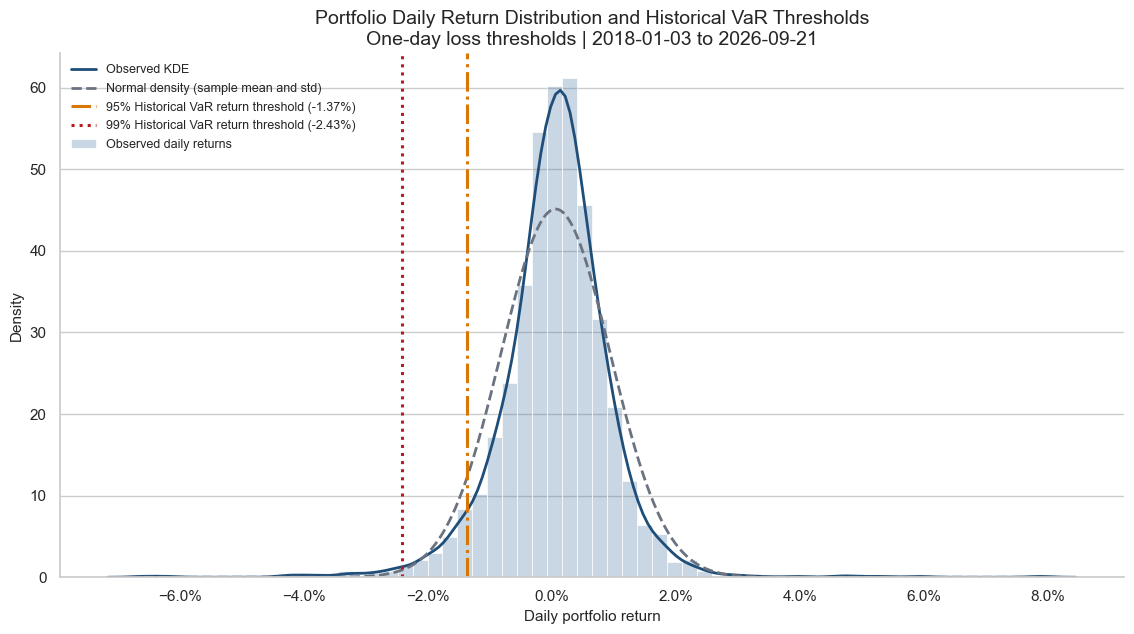

In [8]:
DISTRIBUTION_FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(11.5, 6.5))

sns.histplot(
    portfolio_returns,
    bins=60,
    stat="density",
    color="#4C78A8",
    alpha=0.30,
    edgecolor="white",
    linewidth=0.5,
    label="Observed daily returns",
    ax=ax,
)
sns.kdeplot(
    portfolio_returns,
    color="#1F4E79",
    linewidth=2.0,
    label="Observed KDE",
    ax=ax,
)

x_grid = np.linspace(portfolio_returns.min(), portfolio_returns.max(), 1_000)
ax.plot(
    x_grid,
    norm.pdf(x_grid, loc=mean_return, scale=std_return),
    color="#6B7280",
    linewidth=2.0,
    linestyle="--",
    label="Normal density (sample mean and std)",
)

threshold_styles = {
    0.95: {"color": "#D97706", "linestyle": "-."},
    0.99: {"color": "#B91C1C", "linestyle": ":"},
}
for confidence in CONFIDENCE_LEVELS:
    return_threshold = -historical_estimates[confidence]["VaR"]
    ax.axvline(
        return_threshold,
        linewidth=2.2,
        label=(
            f"{confidence:.0%} Historical VaR return threshold "
            f"({return_threshold:.2%})"
        ),
        **threshold_styles[confidence],
    )

ax.set_title(
    "Portfolio Daily Return Distribution and Historical VaR Thresholds\n"
    f"One-day loss thresholds | {sample_start.date()} to {sample_end.date()}"
)
ax.set_xlabel("Daily portfolio return")
ax.set_ylabel("Density")
ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig(DISTRIBUTION_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()

### 8.3 Static VaR and ES Comparison

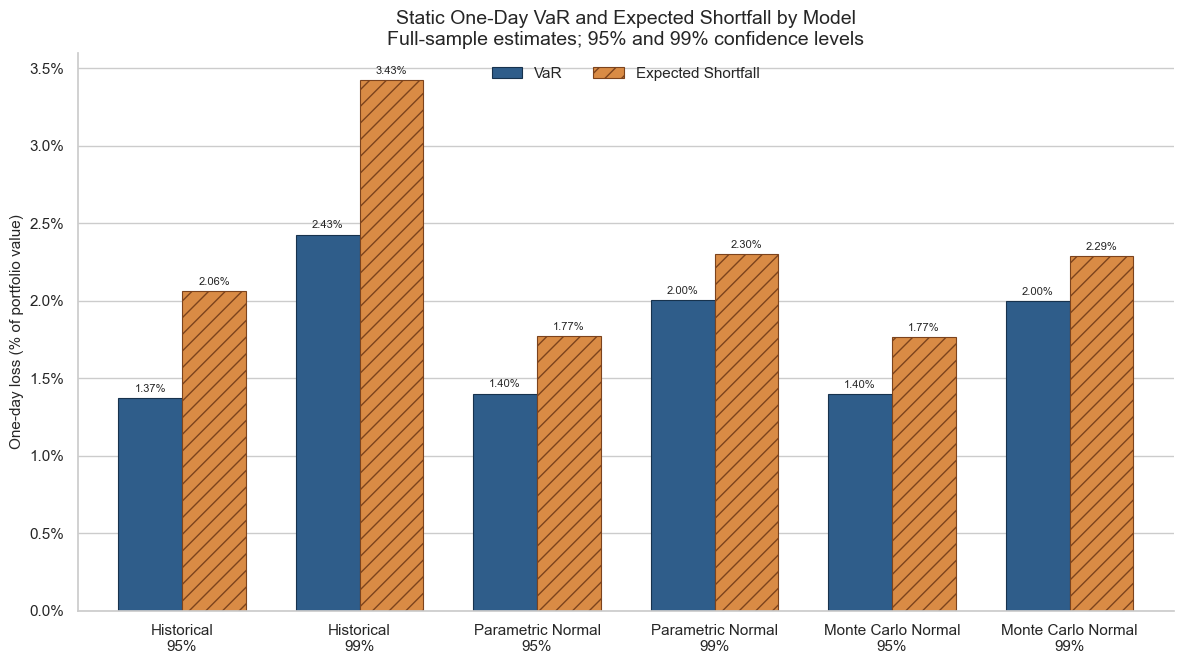

In [9]:
comparison = results_table.copy()
comparison["Group_Label"] = (
    comparison["Model"]
    + "\n"
    + comparison["Confidence_Level"].map(lambda value: f"{value:.0%}")
)
x_positions = np.arange(len(comparison))
bar_width = 0.36

fig, ax = plt.subplots(figsize=(12, 6.8))
var_bars = ax.bar(
    x_positions - bar_width / 2,
    comparison["VaR_Return"],
    width=bar_width,
    color="#2F5D8A",
    edgecolor="#17324D",
    linewidth=0.8,
    label="VaR",
)
es_bars = ax.bar(
    x_positions + bar_width / 2,
    comparison["ES_Return"],
    width=bar_width,
    color="#D98B45",
    edgecolor="#7C431D",
    linewidth=0.8,
    hatch="//",
    label="Expected Shortfall",
)

ax.bar_label(var_bars, labels=[f"{value:.2%}" for value in comparison["VaR_Return"]], padding=3, fontsize=8)
ax.bar_label(es_bars, labels=[f"{value:.2%}" for value in comparison["ES_Return"]], padding=3, fontsize=8)
ax.set_xticks(x_positions, comparison["Group_Label"])
ax.set_ylabel("One-day loss (% of portfolio value)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
ax.set_title(
    "Static One-Day VaR and Expected Shortfall by Model\n"
    "Full-sample estimates; 95% and 99% confidence levels"
)
ax.legend(loc="upper center", ncol=2)
ax.grid(axis="x", visible=False)
ax.margins(x=0.04)
fig.tight_layout()
fig.savefig(COMPARISON_FIGURE_PATH, dpi=220, bbox_inches="tight")
plt.show()

### 8.4 Save and Re-Validate the Numeric Results

In [10]:
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
results_table.to_csv(RESULTS_PATH, index=False)

saved_results = pd.read_csv(RESULTS_PATH)
assert saved_results.shape == results_table.shape
assert saved_results["Model"].tolist() == results_table["Model"].tolist()
assert np.allclose(
    saved_results[numeric_risk_columns].to_numpy(dtype="float64"),
    results_table[numeric_risk_columns].to_numpy(dtype="float64"),
    rtol=1e-12,
    atol=1e-15,
)
assert saved_results["Sample_Start"].eq(sample_start.date().isoformat()).all()
assert saved_results["Sample_End"].eq(sample_end.date().isoformat()).all()
assert saved_results["Holding_Period"].eq(HOLDING_PERIOD).all()
assert RESULTS_PATH.stat().st_size > 0
assert DISTRIBUTION_FIGURE_PATH.stat().st_size > 0
assert COMPARISON_FIGURE_PATH.stat().st_size > 0

output_summary = pd.Series(
    {
        "Results CSV": RESULTS_PATH.relative_to(project_root),
        "Results rows": len(saved_results),
        "Distribution figure": DISTRIBUTION_FIGURE_PATH.relative_to(
            project_root
        ),
        "Comparison figure": COMPARISON_FIGURE_PATH.relative_to(project_root),
        "Monte Carlo simulations": SIMULATIONS,
        "Random seed": RANDOM_SEED,
        "Validation status": "Passed",
    },
    name="Output validation",
)
display(output_summary.to_frame())

,Output validation
Results CSV,outputs/tables/static_var_es_results.csv
Results rows,6
Distribution figure,outputs/figures/portfolio_return_distribution.png
Comparison figure,outputs/figures/static_var_es_comparison.png
Monte Carlo simulations,100000
Random seed,42
Validation status,Passed


## 9. Interpretation and Limitations

- **Tail shape:** Skewness is mildly negative, while excess kurtosis is strongly positive. The key Normal-model weakness in this sample is therefore tail thickness more than pronounced asymmetry.
- **Model comparison:** Historical 99% VaR (`2.427%`) and ES (`3.427%`) exceed Parametric Normal (`2.003%`, `2.303%`) and Monte Carlo Normal (`1.998%`, `2.287%`). At 95%, Parametric and Monte Carlo VaR are slightly above Historical VaR, so no model is uniformly most conservative across all measures.
- **Why Normal risk can be understated:** Mean and standard deviation do not reproduce the sample's high excess kurtosis. The gap is most visible in 99% tail severity and Historical ES.
- **Historical-model constraint:** The static Historical estimates use the full 2,190-observation sample—not the 250-day rolling window used in the next notebook—but they still depend on the selected 2018–2026 regimes and treat all observations equally. Only 22 observations lie at or beyond the interpolated 99% VaR threshold. The explicit `method="linear"` quantile followed by a simple mean of observations satisfying `loss >= VaR` is transparent and reproducible, but it is not an exact probability-weighted ES estimator at the interpolated quantile boundary. With few tail observations, the resulting ES is sensitive to individual extreme losses.
- **Why ES adds information:** VaR identifies a cutoff. ES reports the average loss after crossing that cutoff, so it distinguishes tails with similar quantiles but different loss severity.
- **Validation boundary:** These are full-sample static estimates. Reusing the same observations for estimation and description does not test forecast calibration, independence of breaches, or performance through time.

## 10. Key Takeaways

- On USD 1,000,000, Historical risk ranges from about USD 13,701 VaR / USD 20,605 ES at 95% to USD 24,275 VaR / USD 34,268 ES at 99%.
- Parametric Normal and Monte Carlo Normal estimates are close because they share the same Normal assumption; this confirms implementation consistency, not model adequacy.
- The observed excess kurtosis makes tail-model choice consequential, especially at 99% and for ES.
- All estimates use aligned processed returns, a one-day horizon, explicit signs and quantile rules, and reproducible Monte Carlo sampling.
- The next stage should use rolling estimation windows and genuinely out-of-sample forecasts before applying coverage and independence backtests.